
# AI-Based Smart Power Usage Prediction System

## Abstract
This notebook implements a smart electricity forecasting prototype that predicts the **next 6-hour average power demand**, compares deep and baseline models, uses a **weighted ensemble** for robust accuracy, and predicts the **next-day peak hour** for backup power scheduling.

## Objectives
- Build a reliable 6-hour-ahead forecasting model
- Compare deep learning, baseline, and weighted ensemble regressors
- Track MAE, RMSE, R², RAE, and Relative Accuracy
- Predict which hour is likely to be the day’s peak load for operational planning


## Quick Start: Training Modes

Three training profiles are available for different use cases:

| Mode | Runtime | Use Case | Models |
|------|---------|----------|--------|
| **fast** | ~50s (local 50K rows) | Quick iteration, prototyping | Linear, MLP Compact, GB |
| **balanced** | ~2min (local 180K rows) | Development, testing | Linear, MLP Compact, MLP Deep, GB |
| **full** | 5–10min+ (all data) | Final evaluation, production | Linear, MLP Compact, MLP Deep, GB (more estimators) |

**To use:** Edit the `MODEL_PROFILE` variable in the next cell to `"fast"`, `"balanced"`, or `"full"`. 
Also set `MAX_ROWS` to cap the dataset for faster iteration (use `0` for no limit and full accuracy).


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

In [3]:
# ============================================================================
# TRAINING MODE CONFIGURATION (fast | balanced | full)
# ============================================================================
# Choose training profile for faster iteration vs. higher accuracy:
#   - "fast":      Quick experiments, fewer models, lighter hyperparams (~50s local)
#   - "balanced":  Mid-tier, good trade-off between speed & quality (~120s local)
#   - "full":      Comprehensive training, all models, tuned hyperparams (longer)

MODEL_PROFILE = "fast"  # Change to "balanced" or "full" for better accuracy
MAX_ROWS = 180_000  # Cap raw data rows for faster iteration (0 = use all)

print(f"Training profile: {MODEL_PROFILE}")
print(f"Max rows cap: {MAX_ROWS if MAX_ROWS > 0 else 'No limit'}")

Training profile: fast
Max rows cap: 180000


In [ ]:
# If needed, install dataset helper package
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# UCI dataset: Individual Household Electric Power Consumption
dataset = fetch_ucirepo(id=235)
raw_df = dataset.data.features.copy() # type: ignore

print(f"Dataset: {dataset.metadata['name']}") # type: ignore
print(f"Raw shape: {raw_df.shape}")
raw_df.head()

In [ ]:
DATASET_NAME = "household_power_consumption.csv"
candidate_paths = [
    Path(f"./data/{DATASET_NAME}"),
    Path(f"./AI/data/{DATASET_NAME}"),
    Path(f"/home/temi/Documents/ML/AI/data/{DATASET_NAME}"),
    Path(f"/content/{DATASET_NAME}"),
]

for p in candidate_paths:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError("Could not locate household_power_consumption.csv")

raw_df = pd.read_csv(data_path, sep=";", na_values=["?"])

# Apply MAX_ROWS cap for faster iteration if needed
if MAX_ROWS > 0 and len(raw_df) > MAX_ROWS:
    raw_df = raw_df.tail(MAX_ROWS).copy()
    print(f"Capped to last {MAX_ROWS} rows")

print(f"Loaded data from: {data_path}")
print(f"Shape: {raw_df.shape}")
raw_df.head()

Capped to last 180000 rows
Loaded data from: data/household_power_consumption.csv
Shape: (180000, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1895259,24/7/2010,21:03:00,1.370,0.092,242.78,5.6,0.0,1.0,1.0
1895260,24/7/2010,21:04:00,1.376,0.092,243.08,5.6,0.0,2.0,0.0
1895261,24/7/2010,21:05:00,1.374,0.094,243.28,5.6,0.0,1.0,1.0
1895262,24/7/2010,21:06:00,1.382,0.094,243.59,5.6,0.0,2.0,1.0
1895263,24/7/2010,21:07:00,1.362,0.092,242.78,5.6,0.0,1.0,0.0


In [5]:
df = raw_df.copy()

numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce",
)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=["datetime", "Global_active_power", "Voltage", "Global_intensity"]
)
df = df.sort_values("datetime")

df_hourly = (
    df.set_index("datetime")[["Global_active_power", "Voltage", "Global_intensity"]]
    .resample("h")
    .mean()
    .dropna()
)

print("Hourly dataset shape:", df_hourly.shape)
df_hourly.head()

Hourly dataset shape: (2795, 3)


,Global_active_power,Voltage,Global_intensity
datetime,,,
2010-07-24 21:00:00,1.774246,242.190526,7.400000
2010-07-24 22:00:00,1.230267,242.374000,5.113333
2010-07-24 23:00:00,1.132200,242.642667,4.690000
2010-07-25 00:00:00,1.092000,238.057667,4.580000
2010-07-25 01:00:00,0.901367,238.188833,3.820000


In [6]:
FORECAST_HORIZON = 6

model_df = df_hourly.copy()

# Target: average demand over next 6 hours
future_power = pd.concat(
    [
        model_df["Global_active_power"].shift(-step)
        for step in range(1, FORECAST_HORIZON + 1)
    ],
    axis=1,
)
model_df["target_next_6h_avg"] = future_power.mean(axis=1)

# Time features
model_df["hour"] = model_df.index.hour
model_df["day_of_week"] = model_df.index.dayofweek
model_df["day_of_year"] = model_df.index.dayofyear
model_df["month"] = model_df.index.month
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24.0)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24.0)

# Lag features
for lag in [1, 2, 3, 6, 12, 24, 48]:
    model_df[f"power_lag_{lag}"] = model_df["Global_active_power"].shift(lag)
    model_df[f"voltage_lag_{lag}"] = model_df["Voltage"].shift(lag)
    model_df[f"current_lag_{lag}"] = model_df["Global_intensity"].shift(lag)

# Rolling statistics
for window in [3, 6, 12, 24]:
    model_df[f"power_roll_mean_{window}"] = (
        model_df["Global_active_power"].rolling(window).mean()
    )
    model_df[f"power_roll_std_{window}"] = (
        model_df["Global_active_power"].rolling(window).std()
    )
    model_df[f"current_roll_mean_{window}"] = (
        model_df["Global_intensity"].rolling(window).mean()
    )

model_df = model_df.dropna()
print("Model-ready shape:", model_df.shape)
model_df.head()

Model-ready shape: (2746, 44)


,Global_active_power,Voltage,Global_intensity,target_next_6h_avg,hour,day_of_week,day_of_year,month,is_weekend,hour_sin,hour_cos,power_lag_1,voltage_lag_1,current_lag_1,power_lag_2,voltage_lag_2,current_lag_2,power_lag_3,voltage_lag_3,current_lag_3,power_lag_6,voltage_lag_6,current_lag_6,power_lag_12,voltage_lag_12,current_lag_12,power_lag_24,voltage_lag_24,current_lag_24,power_lag_48,voltage_lag_48,current_lag_48,power_roll_mean_3,power_roll_std_3,current_roll_mean_3,power_roll_mean_6,power_roll_std_6,current_roll_mean_6,power_roll_mean_12,power_roll_std_12,current_roll_mean_12,power_roll_mean_24,power_roll_std_24,current_roll_mean_24
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-07-26 21:00:00,1.144267,240.205167,4.760000,1.402639,21,0,207,7,0,-0.707107,0.707107,0.324233,242.311667,1.493333,0.295033,241.788333,1.380000,0.348300,241.125333,1.623333,0.295733,241.302667,1.300000,0.412433,240.879667,1.890000,0.641667,242.587500,2.616667,1.774246,242.190526,7.400000,0.587844,0.482097,2.544444,0.453822,0.339331,1.997222,0.501144,0.314657,2.188056,0.593083,0.598286,2.575833
2010-07-26 22:00:00,2.091267,240.119167,8.683333,1.102389,22,0,207,7,0,-0.500000,0.866025,1.144267,240.205167,4.760000,0.324233,242.311667,1.493333,0.295033,241.788333,1.380000,0.336400,241.118167,1.543333,0.743233,239.296833,3.180000,0.652267,243.251667,2.640000,1.230267,242.374000,5.113333,1.186589,0.884277,4.978889,0.746300,0.738905,3.187222,0.613481,0.556576,2.646667,0.653042,0.672036,2.827639
2010-07-26 23:00:00,1.894200,241.787000,7.770000,0.838611,23,0,207,7,0,-0.258819,0.965926,2.091267,240.119167,8.683333,1.144267,240.205167,4.760000,0.324233,242.311667,1.493333,0.274700,240.246667,1.183333,1.083233,239.256000,4.596667,2.831367,243.041000,11.833333,1.132200,242.642667,4.690000,1.709911,0.499674,7.071111,1.016217,0.823170,4.285000,0.681061,0.658671,2.911111,0.613993,0.557413,2.658333
2010-07-27 00:00:00,1.645633,241.080167,6.770000,0.614572,0,1,208,7,0,0.000000,1.000000,1.894200,241.787000,7.770000,2.091267,240.119167,8.683333,1.144267,240.205167,4.760000,0.348300,241.125333,1.623333,0.513167,239.641333,2.203333,0.340633,243.254667,1.490000,1.092000,238.057667,4.580000,1.877033,0.223312,7.741111,1.232439,0.781995,5.142778,0.775433,0.711443,3.291667,0.668368,0.592156,2.878333
2010-07-27 01:00:00,1.617767,238.417000,6.810000,0.398322,1,1,208,7,0,0.258819,0.965926,1.645633,241.080167,6.770000,1.894200,241.787000,7.770000,2.091267,240.119167,8.683333,0.295033,241.788333,1.380000,0.329967,241.130167,1.500000,0.338800,241.188667,1.513333,0.901367,238.188833,3.820000,1.719200,0.152194,7.116667,1.452894,0.638080,6.047778,0.882750,0.734880,3.734167,0.721658,0.618185,3.099028


In [7]:
def relative_absolute_error(y_true, y_pred):
    den = np.abs(y_true - np.mean(y_true)).sum()
    if den == 0:
        return 0.0
    num = np.abs(y_true - y_pred).sum()
    return float(num / den)


target_col = "target_next_6h_avg"
feature_cols = [c for c in model_df.columns if c != target_col]

X = model_df[feature_cols]
y = model_df[target_col]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = model_df.index[split_idx:]

# small validation split used only for ensemble weights
val_split_idx = int(len(X_train) * 0.8)
X_fit, X_val = X_train.iloc[:val_split_idx], X_train.iloc[val_split_idx:]
y_fit, y_val = y_train.iloc[:val_split_idx], y_train.iloc[val_split_idx:]

# Build model set based on profile
if MODEL_PROFILE == "fast":
    models = {
        "Linear Regression": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", LinearRegression()),
            ]
        ),
        "MLP Compact": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(32, 16),
                        activation="relu",
                        max_iter=120,
                        early_stopping=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=220,
            learning_rate=0.03,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    }
elif MODEL_PROFILE == "full":
    models = {
        "Linear Regression": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", LinearRegression()),
            ]
        ),
        "MLP Compact": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(64, 32),
                        activation="relu",
                        max_iter=800,
                        early_stopping=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "MLP Deep": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(128, 64, 32),
                        activation="relu",
                        max_iter=1000,
                        early_stopping=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=420,
            learning_rate=0.03,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    }
else:  # balanced (default)
    models = {
        "Linear Regression": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", LinearRegression()),
            ]
        ),
        "MLP Compact": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(64, 32),
                        activation="relu",
                        max_iter=600,
                        early_stopping=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "MLP Deep": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(128, 64, 32),
                        activation="relu",
                        max_iter=850,
                        early_stopping=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=350,
            learning_rate=0.03,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    }

results = []
predictions = {}
fitted_models = {}
validation_rmse = {}

for name, model in models.items():
    model.fit(X_fit, y_fit)
    y_val_pred = model.predict(X_val)
    validation_rmse[name] = np.sqrt(mean_squared_error(y_val, y_val_pred))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rae = relative_absolute_error(y_test.values, y_pred)
    results.append(
        {
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "RAE": rae,
            "Relative_Accuracy": 1.0 - rae,
        }
    )
    predictions[name] = y_pred
    fitted_models[name] = model

# Weighted ensemble (inverse validation RMSE)
inv_errors = {k: 1.0 / max(v, 1e-8) for k, v in validation_rmse.items()}
inv_total = sum(inv_errors.values())
ensemble_weights = {k: v / inv_total for k, v in inv_errors.items()}

ensemble_pred = np.zeros(len(y_test), dtype=float)
for model_name, y_pred in predictions.items():
    ensemble_pred += ensemble_weights[model_name] * y_pred

ensemble_rae = relative_absolute_error(y_test.values, ensemble_pred)
results.append(
    {
        "Model": "Weighted Ensemble",
        "MAE": mean_absolute_error(y_test, ensemble_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, ensemble_pred)),
        "R2": r2_score(y_test, ensemble_pred),
        "RAE": ensemble_rae,
        "Relative_Accuracy": 1.0 - ensemble_rae,
    }
)

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
best_model_name = results_df.loc[0, "Model"]

if best_model_name == "Weighted Ensemble":
    best_pred = ensemble_pred
else:
    best_pred = predictions[best_model_name]

comparison_df = pd.DataFrame(
    {
        "datetime": dates_test,
        "actual": y_test.values,
        "predicted": best_pred,
    }
).set_index("datetime")

print("Best model:", best_model_name)
print("\nEnsemble weights:")
print(pd.Series(ensemble_weights).sort_values(ascending=False))
results_df

Best model: Weighted Ensemble

Ensemble weights:
Gradient Boosting    0.358803
Linear Regression    0.351708
MLP Compact          0.289490
dtype: float64


,Model,MAE,RMSE,R2,RAE,Relative_Accuracy
0,Weighted Ensemble,0.383633,0.484795,0.275207,0.825470,0.174530
1,Gradient Boosting,0.405159,0.526981,0.143576,0.871789,0.128211
2,Linear Regression,0.442473,0.546103,0.080296,0.952077,0.047923
3,MLP Compact,0.451552,0.556033,0.046547,0.971612,0.028388


> **Docstring:** Introduces the hold-out forecast validation section and the metrics used for model assessment.

## Model Evaluation and Forecast Validation

The chart below compares actual and predicted values for the hold-out set using the selected best model. Metrics include error (`MAE`, `RMSE`, `RAE`) and goodness-of-fit (`R²`, `Relative_Accuracy = 1 - RAE`).

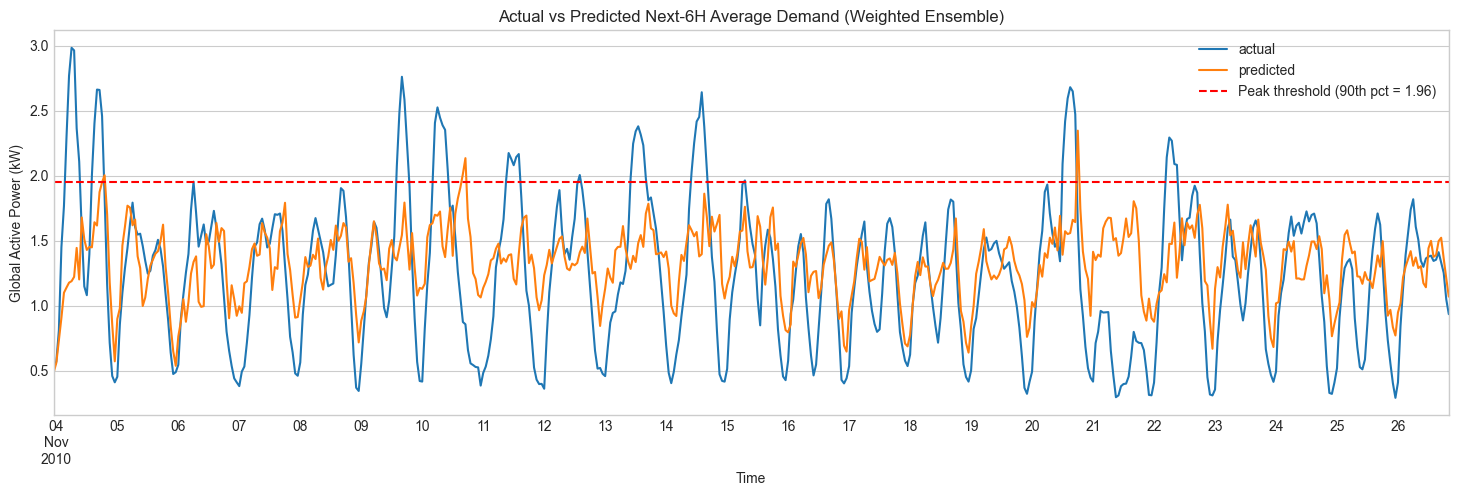

In [16]:
peak_threshold = comparison_df["actual"].quantile(0.90)

fig, ax = plt.subplots(figsize=(18, 5))
comparison_df[["actual", "predicted"]].plot(ax=ax)
ax.axhline(
    peak_threshold,
    color="red",
    linestyle="--",
    label=f"Peak threshold (90th pct = {peak_threshold:.2f})",
)
ax.set_title(f"Actual vs Predicted Next-6H Average Demand ({best_model_name})")
ax.set_ylabel("Global Active Power (kW)")
ax.set_xlabel("Time")
ax.legend()

results_df
plt.savefig('actual_pred.svg', format='svg', bbox_inches='tight')
plt.show()

> **Docstring:** Introduces peak-period detection and next-day peak-hour classification for backup scheduling.

## Peak-Demand Detection + Next-Day Peak-Hour Prediction

We flag high-load periods (90th percentile threshold) and train a daily classifier to estimate the **hour most likely to peak next day**. This supports backup power scheduling decisions.

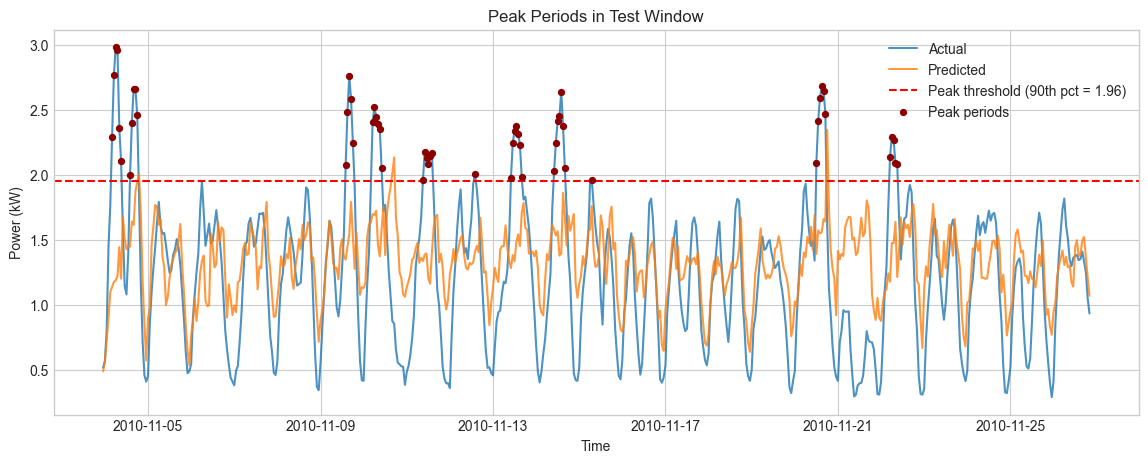

Detected peak periods: 55
Daily peak-hour classifier accuracy: 0.375
Recommended backup window (next day): 07:00 - 07:59


,actual_peak_hour,predicted_peak_hour
date,,
2010-11-03,21,20
2010-11-04,20,12
2010-11-05,7,7
2010-11-06,7,21
2010-11-07,20,7
2010-11-08,21,7
2010-11-09,20,20
2010-11-10,10,19
2010-11-11,15,7


In [11]:
# 1) Peak periods in test window
peak_periods = comparison_df[comparison_df["actual"] >= peak_threshold].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(comparison_df.index, comparison_df["actual"], label="Actual", alpha=0.8)
ax.plot(comparison_df.index, comparison_df["predicted"], label="Predicted", alpha=0.8)
ax.axhline(
    peak_threshold,
    color="red",
    linestyle="--",
    label=f"Peak threshold (90th pct = {peak_threshold:.2f})",
)

if not peak_periods.empty:
    ax.scatter(
        peak_periods.index,
        peak_periods["actual"],
        color="darkred",
        s=18,
        label="Peak periods",
        zorder=4,
    )

ax.set_title("Peak Periods in Test Window")
ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
ax.legend()
plt.show()

print(f"Detected peak periods: {len(peak_periods)}")

# 2) Daily peak-hour prediction model
daily_df = (
    df_hourly.assign(date=df_hourly.index.date)
    .groupby("date")
    .agg(
        day_mean=("Global_active_power", "mean"),
        day_max=("Global_active_power", "max"),
        day_std=("Global_active_power", "std"),
        peak_hour=("Global_active_power", lambda s: int(s.idxmax().hour)),
    )
)

daily_df.index = pd.to_datetime(daily_df.index)
daily_df["day_of_week"] = daily_df.index.dayofweek
daily_df["month"] = daily_df.index.month
daily_df["is_weekend"] = (daily_df["day_of_week"] >= 5).astype(int)

for c in ["day_mean", "day_max", "day_std"]:
    daily_df[f"prev_{c}"] = daily_df[c].shift(1)

daily_df = daily_df.dropna()
peak_feature_cols = [c for c in daily_df.columns if c != "peak_hour"]

split_daily = int(len(daily_df) * 0.8)
X_peak_train = daily_df.iloc[:split_daily][peak_feature_cols]
y_peak_train = daily_df.iloc[:split_daily]["peak_hour"]
X_peak_test = daily_df.iloc[split_daily:][peak_feature_cols]
y_peak_test = daily_df.iloc[split_daily:]["peak_hour"]

# Build peak-hour model based on profile
if MODEL_PROFILE == "fast":
    peak_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
elif MODEL_PROFILE == "full":
    peak_model = RandomForestClassifier(
        n_estimators=450,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
else:  # balanced
    peak_model = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

peak_model.fit(X_peak_train, y_peak_train)

y_peak_pred = peak_model.predict(X_peak_test)
peak_hour_accuracy = accuracy_score(y_peak_test, y_peak_pred)

latest_features_daily = daily_df.iloc[-1][peak_feature_cols].to_frame().T
predicted_peak_hour_next_day = int(peak_model.predict(latest_features_daily)[0])

print(f"Daily peak-hour classifier accuracy: {peak_hour_accuracy:.3f}")
print(
    f"Recommended backup window (next day): {predicted_peak_hour_next_day:02d}:00 - {predicted_peak_hour_next_day:02d}:59"
)

pd.DataFrame(
    {
        "actual_peak_hour": y_peak_test.values,
        "predicted_peak_hour": y_peak_pred,
    },
    index=y_peak_test.index,
).head(10)

In [12]:
latest_x = X.iloc[-1:].copy()

if best_model_name == "Weighted Ensemble":
    next_6h_pred = 0.0
    for m_name, model in fitted_models.items():
        next_6h_pred += ensemble_weights[m_name] * float(model.predict(latest_x)[0])
else:
    next_6h_pred = float(fitted_models[best_model_name].predict(latest_x)[0])

is_predicted_peak_period = next_6h_pred >= peak_threshold

summary = pd.DataFrame(
    [
        {
            "latest_timestamp": str(model_df.index[-1]),
            "best_model": best_model_name,
            "predicted_next_6h_avg_power_kw": round(next_6h_pred, 4),
            "is_predicted_peak_period": bool(is_predicted_peak_period),
            "predicted_peak_hour_next_day": int(predicted_peak_hour_next_day),
            "backup_power_time_window": f"{predicted_peak_hour_next_day:02d}:00 - {predicted_peak_hour_next_day:02d}:59",
        }
    ]
)

summary

,latest_timestamp,best_model,predicted_next_6h_avg_power_kw,is_predicted_peak_period,predicted_peak_hour_next_day,backup_power_time_window
0,2010-11-26 20:00:00,Weighted Ensemble,1.0697,False,7,07:00 - 07:59
